# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-07-21 09:00:00+09:00,64544.050781,64807.140625,64203.468750,64665.828125,0,0.0,0.0
2026-07-21 09:15:00+09:00,64648.308594,65055.519531,64365.789062,64986.589844,0,0.0,0.0
2026-07-21 09:30:00+09:00,64970.339844,65138.968750,64792.308594,64883.191406,0,0.0,0.0
2026-07-21 09:45:00+09:00,64875.398438,64976.371094,64716.769531,64855.230469,0,0.0,0.0
2026-07-21 10:00:00+09:00,64841.191406,65195.460938,64599.570312,65190.859375,0,0.0,0.0
2026-07-21 10:15:00+09:00,65191.019531,65467.839844,65122.781250,65464.031250,0,0.0,0.0
2026-07-21 10:30:00+09:00,65469.640625,65642.593750,65180.789062,65199.750000,0,0.0,0.0
2026-07-21 10:45:00+09:00,65193.750000,65418.511719,65187.269531,65197.660156,0,0.0,0.0
2026-07-21 11:00:00+09:00,65220.000000,65409.539062,65080.980469,65116.390625,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-07-21 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-07-21 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
#lastclose = 69317.50 # 6/15 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-07-14 00:00:00+09:00    67743.500000
2026-07-15 00:00:00+09:00    68751.507812
2026-07-16 00:00:00+09:00    66835.539062
2026-07-17 00:00:00+09:00    64141.121094
2026-07-21 00:00:00+09:00    66232.187500
Name: Close, dtype: float64


Date
2026-07-17 00:00:00+09:00    64141.121094
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+402.93


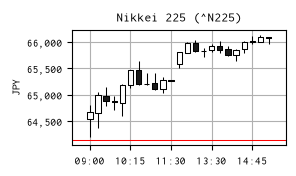

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-07-20 08:00:00+09:00,162.503998,162.535995,162.472000,162.529999,0,0.0,0.0
2026-07-20 08:15:00+09:00,162.524994,162.537003,162.496002,162.528000,0,0.0,0.0
2026-07-20 08:30:00+09:00,162.524994,162.548004,162.511002,162.513000,0,0.0,0.0
2026-07-20 08:45:00+09:00,162.518005,162.546997,162.496994,162.511993,0,0.0,0.0
2026-07-20 09:00:00+09:00,162.511993,162.537994,162.488998,162.494003,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-21 14:45:00+09:00,162.470993,162.518997,162.462006,162.507004,0,0.0,0.0
2026-07-21 15:00:00+09:00,162.503006,162.526993,162.479996,162.520996,0,0.0,0.0
2026-07-21 15:15:00+09:00,162.514999,162.529007,162.505005,162.518005,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-07-21 09:00:00+09:00,397.245485,398.864709,395.149325,397.994981
2026-07-21 09:15:00+09:00,397.828386,400.334253,396.089836,399.910078
2026-07-21 09:30:00+09:00,399.797804,400.835470,398.702281,399.261533
2026-07-21 09:45:00+09:00,399.161969,399.783228,398.185965,399.037881
2026-07-21 10:00:00+09:00,398.995704,401.175676,397.508905,401.147361
2026-07-21 10:15:00+09:00,401.242155,402.945948,400.822157,402.922506
2026-07-21 10:30:00+09:00,402.880185,403.944485,401.102680,401.219360
2026-07-21 10:45:00+09:00,401.187373,402.570505,401.147493,401.211435
2026-07-21 11:00:00+09:00,401.329163,402.495485,400.473710,400.691606


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-07-20 15:15:00+09:00


np.float64(162.38499450683594)

前日終値（ドル換算） 394.9941390123325


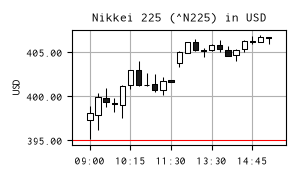

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()